In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
import yfinance as yf
import statsmodels.tsa.api as sm
import matplotlib.dates as mdates
import scipy.stats as stats
import statsmodels.graphics.tsaplots as sgt



In [5]:
FCHI = yf.Ticker("^FCHI")
start_date = dt.datetime(2013, 2,1)
end_date = dt.datetime(2025, 3, 11)
FCHI_df = FCHI.history(start=start_date, end=end_date, auto_adjust=False)

In [6]:
FCHI_df['Log Returns'] = np.log(FCHI_df['Adj Close'] / FCHI_df['Adj Close'].shift(1))
FCHI_df['Squared Returns'] = FCHI_df['Log Returns'] ** 2

In [18]:
fig, axs = plt.subplots(3,1, figsize=(24, 15), sharex=True, dpi=500)
FCHI_df['Adj Close'].plot(ax=axs[0], title='CAC 40 Index Adj Closing Price', color='blue')
FCHI_df['Log Returns'].plot(ax=axs[1], title='CAC 40 Index Log Returns', color='red')
FCHI_df['Squared Returns'].plot(ax=axs[2], title='CAC 40 Index Squared Returns', color='green')

axs[0].xaxis.set_major_locator(mdates.YearLocator())
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.title.set_size(18)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)

plt.legend()
plt.tight_layout()

In [78]:
def summary_statistic(series):
    mean = series.mean() 
    std = series.std(ddof=1) 
    skew = series.skew()
    kurt = series.kurtosis()
    summary = pd.DataFrame([mean, std, skew, kurt], index=['Mean (%)', 'Std (%)', 'Skew', 'Kurt'], columns=['Value'])
    return summary

summary = summary_statistic(FCHI_df['Log Returns'].dropna())
summary

,Value
Mean (%),0.000245
Std (%),0.011565
Skew,-0.794630
Kurt,10.627747


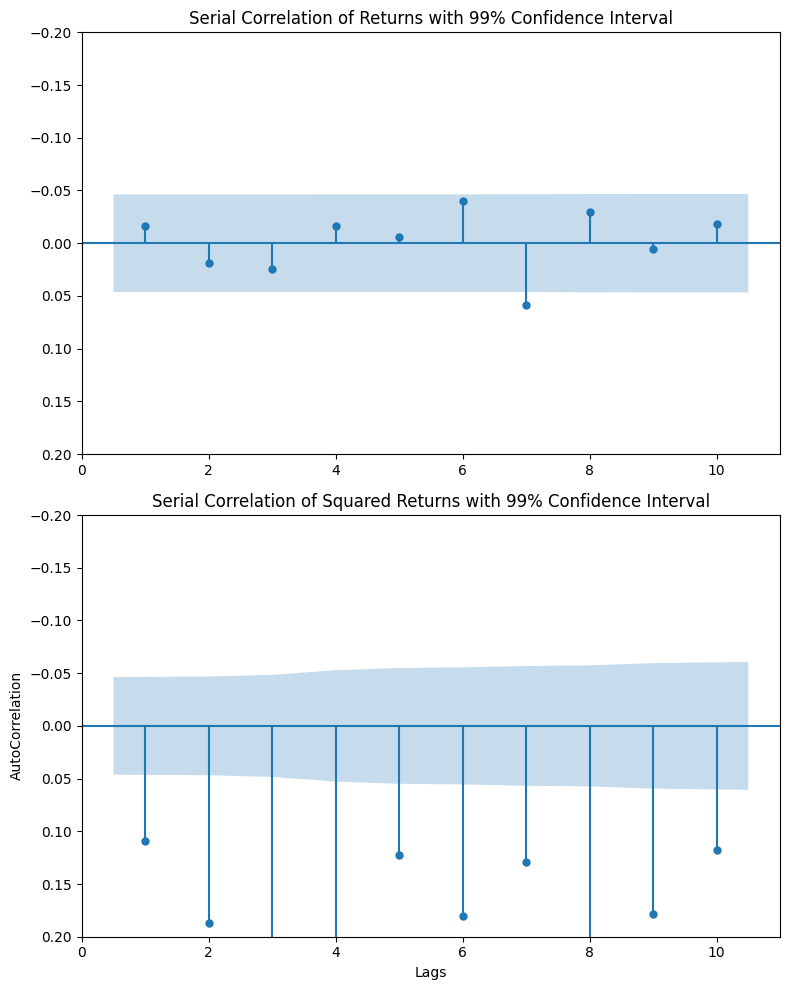

In [30]:
fig, axs = plt.subplots(2,1, figsize =(8,10), sharex = False, sharey = True)
FCHI_acf = sm.acf(FCHI_df['Log Returns'].dropna(), nlags=10)
plot_acf_returns = sgt.plot_acf(FCHI_df['Log Returns'].dropna(), ax=axs[0], lags=10, alpha = 0.01, title='Serial Correlation of Returns with 99% Confidence Interval', zero=False)
plot_acf_squared_returns = sgt.plot_acf(FCHI_df['Squared Returns'].dropna(), lags=10, ax=axs[1], alpha = 0.01, title='Serial Correlation of Squared Returns with 99% Confidence Interval', zero=False)
plt.ylim(0.2, -0.2)
plt.xlabel('Lags')
plt.ylabel('AutoCorrelation')
plt.tight_layout()


AttributeError: Rectangle.set() got an unexpected keyword argument 'normalize'

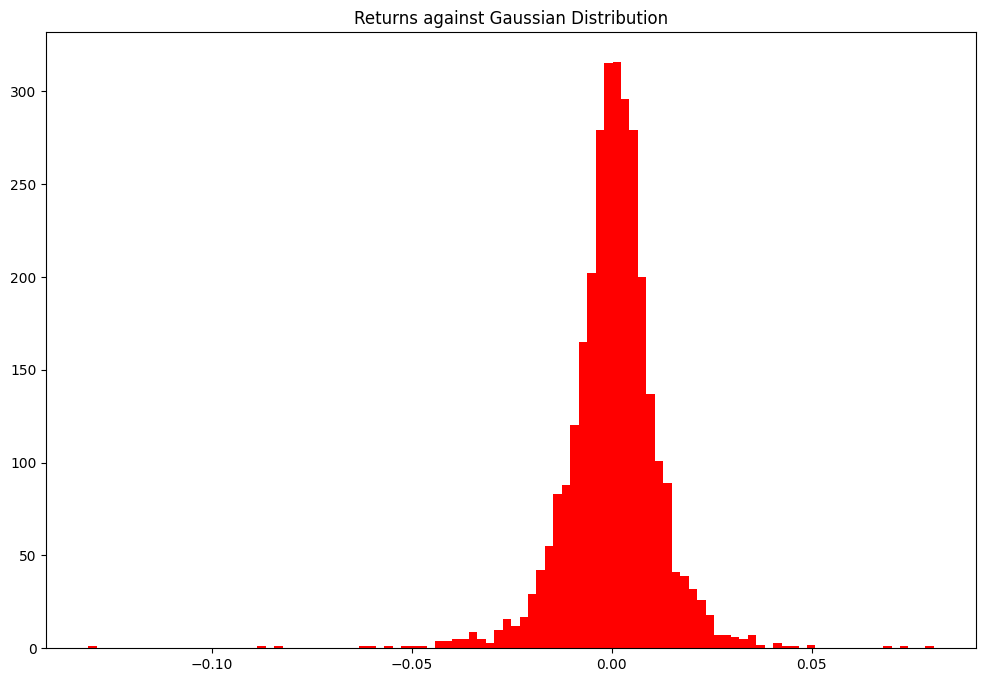

In [ ]:
fig, axs = plt.subplots(1, figsize=(12,8))
plt.title('Returns against Gaussian Distribution')
FCHI_df['Log Returns'].hist(ax=axs, bins=100, color='red', label='Histogram of Log Returns', normalize=True)


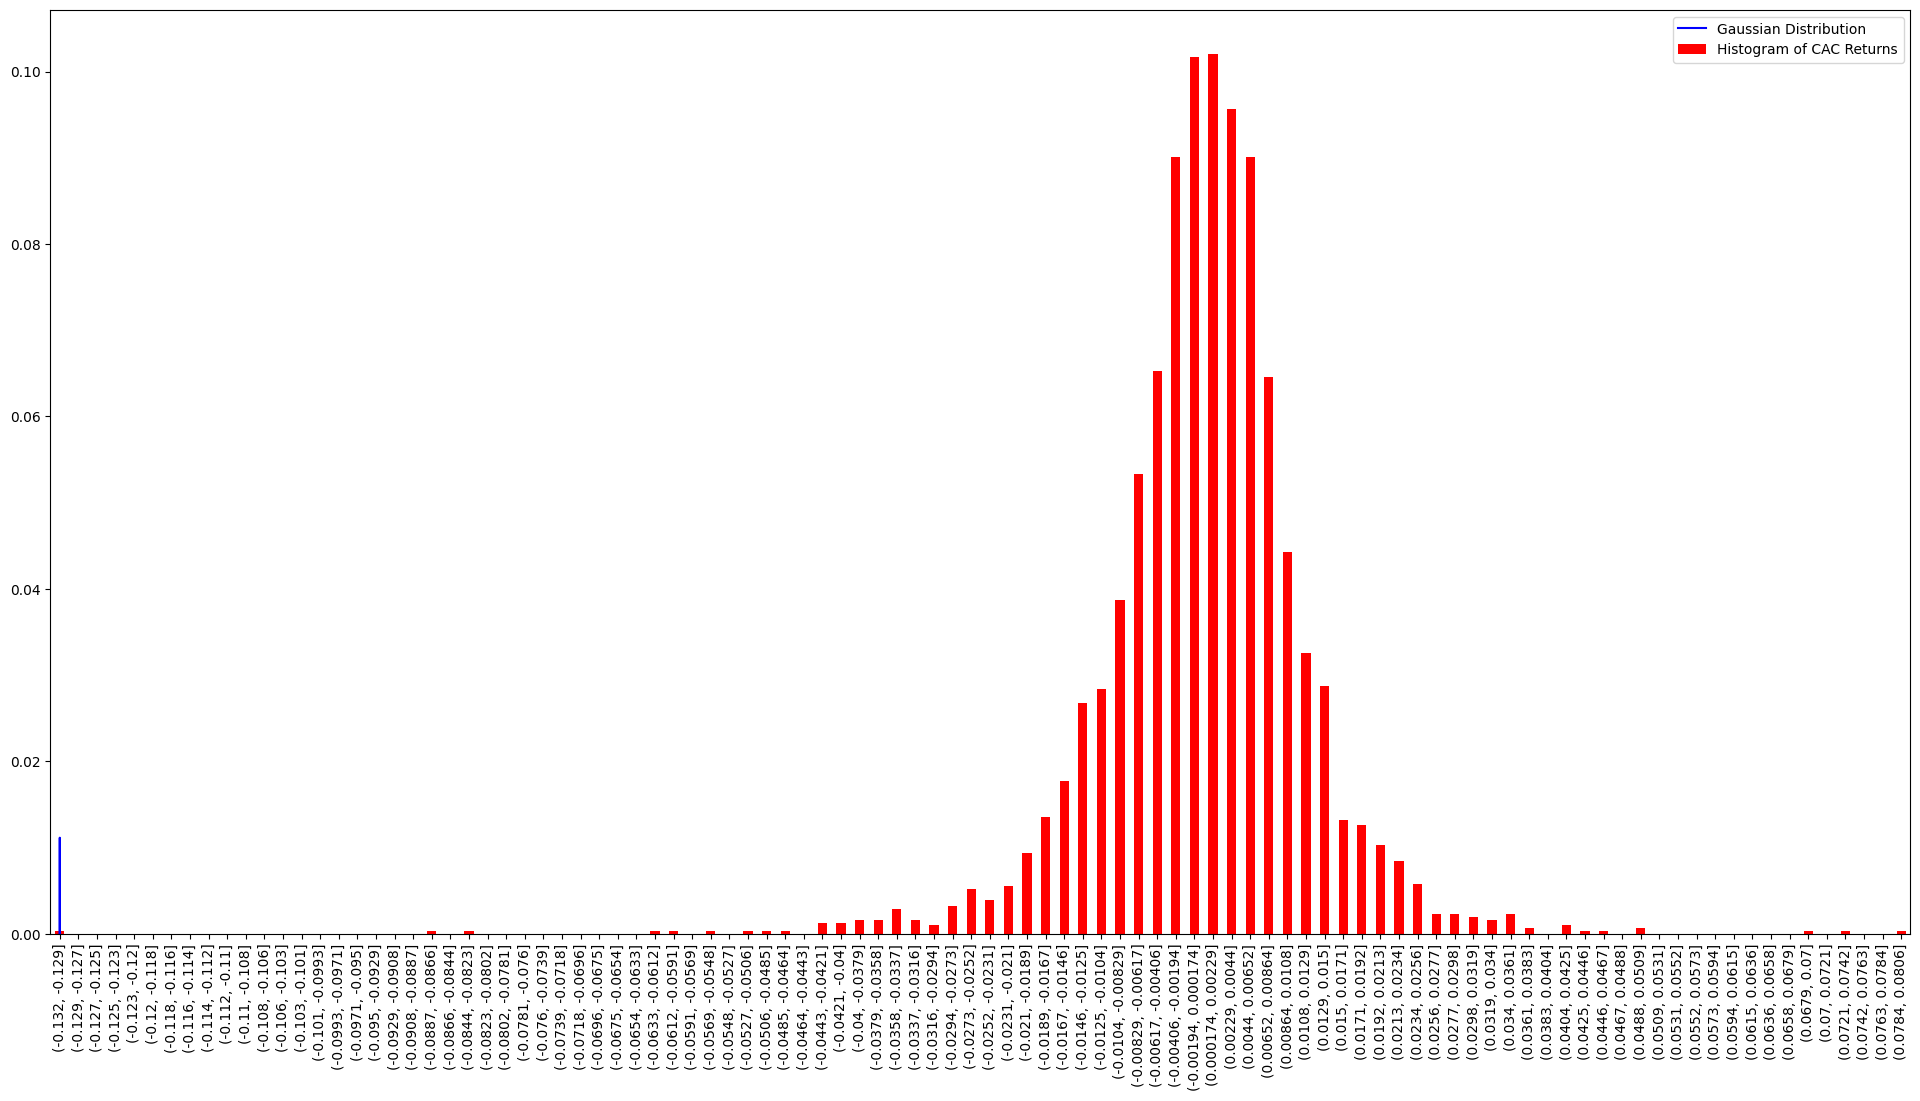

In [141]:
fig, axs = plt.subplots(1, figsize=(24,12), label='Log Returns of CAC', sharex=True, sharey=True)
hist_table = FCHI_df['Log Returns'].value_counts(normalize=True, bins = 100, sort=False)
hist_table.plot.bar(label='Histogram of CAC Returns', color='red', ax=axs)

mean = summary.loc['Mean (%)']['Value'] 
std = summary.loc['Std (%)']['Value']
x= np.linspace(FCHI_df['Log Returns'].min(), FCHI_df['Log Returns'].max(), len(FCHI_df['Log Returns'])) 
plt.plot(x / len(FCHI_df['Log Returns']), stats.norm.pdf(x, mean, std) / len(FCHI_df['Log Returns']), color='blue', label='Gaussian Distribution')
plt.legend()



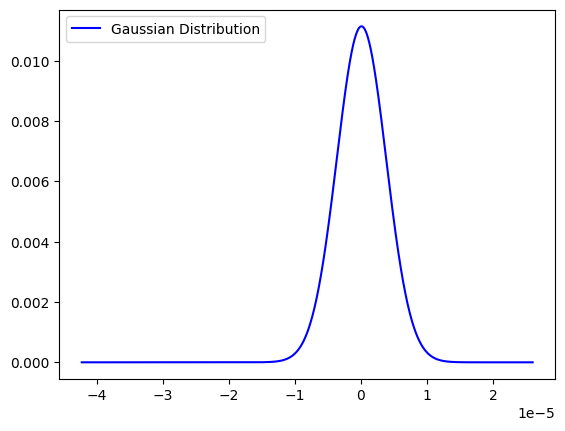